In [18]:
import sys
import os

# Make the project root importable regardless of where Jupyter is launched from
# Adjusted for MVA/faces_tests/ path to reach project root
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('__file__'), '../..')))

import numpy as np
import torch
from PIL import Image
import torchvision.transforms as T
from matplotlib import pyplot as plt

from pnpflow.utils import load_cfg_from_cfg_file, define_model, load_model
from pnpflow.degradations import Denoising, RandomInpainting
from pnpflow.perceptual import PerceptualLoss
import pnpflow.utils as utils

In [19]:
# ── Configuration ──────────────────────────────────────────────────────────────
ROOT    = os.path.abspath(os.path.join(os.path.dirname('__file__'), '../..'))
dataset = 'celeba'

# Load and merge base config, dataset config, and method config
cfg = load_cfg_from_cfg_file(os.path.join(ROOT, 'config/main_config.yaml'))
cfg.update(load_cfg_from_cfg_file(os.path.join(ROOT, f'config/dataset_config/{dataset}.yaml')))

method_config_file = os.path.join(ROOT, f'config/method_config/{cfg.method}.yaml')
cfg.update(load_cfg_from_cfg_file(method_config_file))

method_cfg = load_cfg_from_cfg_file(method_config_file)
cfg.dict_cfg_method = {k: cfg[k] for k in method_cfg.keys()}

cfg.root = ROOT + '/'

In [20]:
# ── Device & Model Initialisation ─────────────────────────────────────────────
device = 'cuda:0'   # change to 'cpu' if no GPU is available
cfg.device = device

model, state = define_model(cfg)
print(f'Model initialised on {device}.')

Model initialised on cuda:0.


In [21]:
# ── Load Pre-trained Weights ───────────────────────────────────────────────────
model_path = os.path.join(ROOT, 'model', dataset, 'ot', 'model_final.pt')
load_model('ot', model, state, download=False,
           checkpoint_path=model_path, dataset=None, device=device)
model.eval()
model = model.to(device)
print('Weights loaded successfully.')

/Data/hamzaazzouzi/Flower/pnpflow/utils.py:225: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device))


Weights loaded successfully.


In [22]:
# ── Non-Isotropic Noise Model Setup ───────────────────────────────────────────
# We consider a spatially-varying Gaussian noise model where the centre
# 50%×50% region of the image has 4× higher noise std than the border:
#
#   y = x + n,   n ~ N(0, R)   with diagonal covariance map R:
#       R(i,j) = 16 σ²   if (i,j) is in the centre patch
#                   σ²   otherwise
#
# FLOWER handles this via the CG data-consistency step which uses R directly,
# so no modification to the prior (flow model) is needed.

dim_image   = 128
num_channels = 3
sigma_noise  = 0.2           # base noise std (border region has σ, centre has 4σ) - updated to 0.2

degradation = Denoising()    # identity-operator forward model  H = I
H  = degradation.H
Ht = degradation.H_adj

# Spatial binary mask: 1 in centre 50%×50% patch, 0 on border
# (increased to 50%x50% to make the noisy centre bigger)
mask1 = torch.zeros((1, num_channels, dim_image, dim_image), device=device)
mask1[:, :, dim_image // 4 : 3 * dim_image // 4,
            dim_image // 4 : 3 * dim_image // 4] = 1.0

# Per-pixel noise variance map R  (diagonal of the full covariance matrix)
R = sigma_noise ** 2 * mask1 * 16 + sigma_noise ** 2 * (1 - mask1)


# ── Flow-Matching Helper Functions ────────────────────────────────────────────

def model_forward(x, t):
    """Evaluate the flow-matching velocity field  v(x, t)."""
    return model(x, t)


# ── Conjugate-Gradient Solver (non-isotropic noise) ──────────────────────────

def BtB(x, H, Ht, lam, R):
    """
    Normal-equation operator for spatially-varying Gaussian noise:
        A x = Hᵀ(H x / R) + x / λ
    where R is the per-pixel noise variance map.
    """
    return Ht(H(x) / R) + x / lam


def cg(b, x0=None, lam=1, max_iter=100, eps=1e-5,
       H=lambda x: x, Ht=lambda x: x, dims=(1, 2, 3), R=1.0):
    """
    Conjugate-gradient solver for  A x = b  where
        A x = Hᵀ(H x / R) + x / λ.

    Parameters
    ----------
    b        : right-hand side tensor
    x0       : initial guess (zeros if None)
    lam      : regularisation weight λ  (= σ_r²)
    max_iter : maximum CG iterations
    eps      : convergence threshold on the residual norm
    H / Ht   : forward / adjoint measurement operators
    dims     : spatial dimensions for inner-product reduction
    R        : per-pixel noise variance map

    Returns
    -------
    x : approximate CG solution
    i : number of iterations performed
    """
    A = lambda x: BtB(x, H, Ht, lam, R)
    x = x0.clone() if x0 is not None else torch.zeros_like(b)

    r = b - A(x)
    r_norm = (r ** 2).sum(dim=dims, keepdim=True)
    p = r.clone()

    with torch.no_grad():
        for i in range(max_iter):
            Ap         = A(p)
            alpha      = r_norm / ((p * Ap).sum(dim=dims, keepdim=True))
            x          = x + alpha * p
            r          = r - alpha * Ap
            r_norm_new = (r ** 2).sum(dim=dims, keepdim=True)
            if r_norm_new.sqrt().all() < eps:
                break
            beta   = r_norm_new / r_norm
            p      = r + beta * p
            r_norm = r_norm_new

    return x, i

Reconstructing image 1/3 (Standard)...
Reconstructing image 1/3 (Emb Mean Prior)...
Reconstructing image 2/3 (Standard)...
Reconstructing image 2/3 (Emb Mean Prior)...
Reconstructing image 3/3 (Standard)...
Reconstructing image 3/3 (Emb Mean Prior)...
Reconstruction complete.


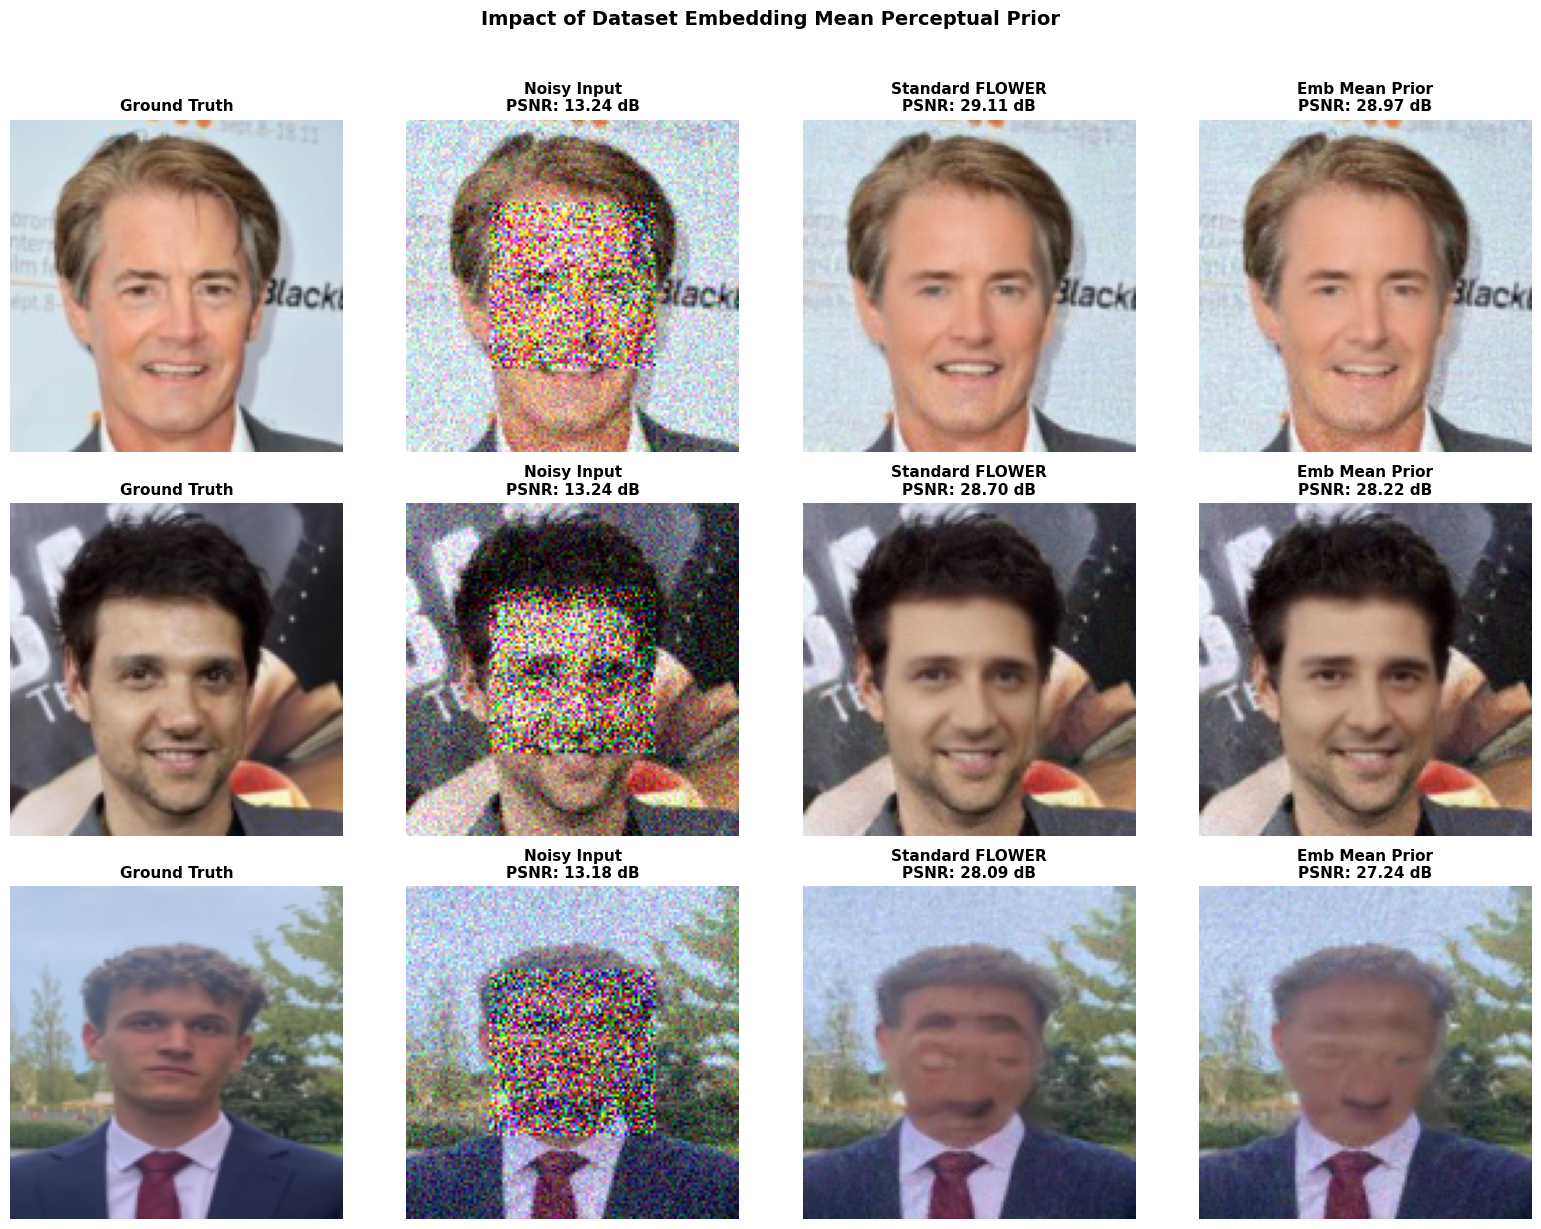

In [17]:
# ── Load Test Images ───────────────────────────────────────────────────────────
load_transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

image_files = [
    os.path.join(ROOT, 'flower_demo', 'celeba_test_43.png'),
    os.path.join(ROOT, 'flower_demo', 'celeba_test_115.png'),
    os.path.join(ROOT, 'flower_demo', 'JUUL.png'),
]

ground_truths = []
for path in image_files:
    img = Image.open(path).convert('RGB')
    ground_truths.append(load_transform(img).unsqueeze(0).to(device))

# ── Pre-compute Dataset Embedding Means ───────────────────────────────────────
# Instead of a mean image, we compute the mean of the feature maps (embeddings)
# of the dataset. This captures the "typical" facial structures in feature space.
perceptual_criterion = PerceptualLoss(device=device)

with torch.no_grad():
    # Helper to get all VGG feature slices for an image
    def get_vgg_embeddings(img):
        img_norm = (img + 1.0) / 2.0
        v_mean = torch.tensor([0.485, 0.456, 0.406], device=img.device).view(1, 3, 1, 1)
        v_std = torch.tensor([0.229, 0.224, 0.225], device=img.device).view(1, 3, 1, 1)
        img_norm = (img_norm - v_mean) / v_std
        
        h1 = perceptual_criterion.slice1(img_norm)
        h2 = perceptual_criterion.slice2(h1)
        h3 = perceptual_criterion.slice3(h2)
        h4 = perceptual_criterion.slice4(h3)
        return [h1, h2, h3, h4]

    # Compute mean embeddings across the test set (as dataset proxy)
    all_embeddings = [get_vgg_embeddings(gt) for gt in ground_truths]
    mean_embeddings = []
    for layer_idx in range(4):
        layer_mean = torch.stack([emb[layer_idx] for emb in all_embeddings]).mean(dim=0)
        mean_embeddings.append(layer_mean)


# ── FLOWER Reconstruction — Perceptual Embedding Mean Prior ───────────────────
steps = 20
delta = 1.0 / steps
lambda_perceptual = 0.05 

results = []

for img_idx, gt in enumerate(ground_truths):
    # Simulate non-isotropic noisy observation
    y = H(gt) \
        + sigma_noise * 4 * torch.randn_like(gt) * mask1 \
        + sigma_noise     * torch.randn_like(gt) * (1 - mask1)

    def run_reconstruction(y_obs, mode='standard'):
        x = torch.randn_like(gt)
        ones = torch.ones(len(x), device=device)
        
        for it in range(steps):
            t = delta * it
            sigma_r = (1 - t) / np.sqrt(t ** 2 + (1 - t) ** 2)
            x_hat_1 = x + (1 - t) * model_forward(x, ones * t)
            x_hat_1_const = x_hat_1.detach()
            lam = sigma_r ** 2
            
            if mode == 'standard':
                b = Ht(y_obs / R) + x_hat_1_const / lam
                x_star, _ = cg(b, x_hat_1_const, lam, max_iter=50, eps=1e-5, H=H, Ht=Ht, R=R)
            
            elif mode == 'perceptual_emb_mean':
                # Unified Proximal step:
                # x* = argmin_u  1/2 ||(y - Hu)||^2_R^-1 + 1/(2λ) ||u - x_hat_1||^2 
                #                + λ_p * Dist(Embeddings(u), Mean_Dataset_Embeddings)
                u = x_hat_1_const.clone().detach().requires_grad_(True)
                optimizer = torch.optim.Adam([u], lr=2e-2)
                
                for _ in range(15):
                    optimizer.zero_grad()
                    
                    # 1. Data Fidelity & 2. Prior Term
                    data_fidelity = 0.5 * torch.sum(((y_obs - H(u)) ** 2) / R)
                    prior_term = (0.5 / lam) * torch.sum((u - x_hat_1_const) ** 2)
                    
                    # 3. Embedding-based Perceptual Loss
                    # We compute the distance between the CURRENT embeddings and the DATASET MEAN embeddings
                    u_norm = (u + 1.0) / 2.0
                    v_mean = torch.tensor([0.485, 0.456, 0.406], device=u.device).view(1, 3, 1, 1)
                    v_std = torch.tensor([0.229, 0.224, 0.225], device=u.device).view(1, 3, 1, 1)
                    u_norm = (u_norm - v_mean) / v_std
                    
                    h_u = [perceptual_criterion.slice1(u_norm)]
                    h_u.append(perceptual_criterion.slice2(h_u[-1]))
                    h_u.append(perceptual_criterion.slice3(h_u[-1]))
                    h_u.append(perceptual_criterion.slice4(h_u[-1]))
                    
                    perc_loss = sum(torch.mean(torch.abs(hu - h_mean)) 
                                    for hu, h_mean in zip(h_u, mean_embeddings))
                    
                    total_objective = data_fidelity + prior_term + lambda_perceptual * perc_loss
                    total_objective.backward()
                    optimizer.step()
                
                x_star = u.detach()

            z0 = torch.randn_like(x)
            estimated_iso_cov = 1 - t - delta
            x = (t + delta) * x_star + estimated_iso_cov * z0
            
        return x.detach()

    print(f'Reconstructing image {img_idx + 1}/{len(ground_truths)} (Standard)...')
    rec_standard = run_reconstruction(y, mode='standard')
    
    print(f'Reconstructing image {img_idx + 1}/{len(ground_truths)} (Emb Mean Prior)...')
    rec_perceptual = run_reconstruction(y, mode='perceptual_emb_mean')

    results.append((gt.detach(), y.detach(), rec_standard, rec_perceptual))

print('Reconstruction complete.')


# ── Visualise Results ─────────────────────────────────────────────────────────
def to_numpy_img(t):
    t = t.squeeze(0).cpu().float()
    t = (t * 0.5 + 0.5).clamp(0, 1)
    return t.permute(1, 2, 0).numpy()

col_titles = ['Ground Truth', 'Noisy Input', 'Standard FLOWER', 'Emb Mean Prior']
fig, axes = plt.subplots(len(results), 4, figsize=(16, 4 * len(results)))

for row_idx, (gt, noisy, rec_std, rec_per) in enumerate(results):
    psnr_noisy = utils.compute_psnr_func(gt, noisy, cfg)
    psnr_std   = utils.compute_psnr_func(gt, rec_std, cfg)
    psnr_per   = utils.compute_psnr_func(gt, rec_per, cfg)
    
    imgs = [gt, noisy, rec_std, rec_per]
    psnrs = [None, psnr_noisy, psnr_std, psnr_per]
    
    for col_idx, (img_t, psnr) in enumerate(zip(imgs, psnrs)):
        ax = axes[row_idx, col_idx]
        ax.imshow(to_numpy_img(img_t))
        ax.axis('off')
        title = col_titles[col_idx]
        if psnr is not None:
            title += f'\nPSNR: {psnr:.2f} dB'
        ax.set_title(title, fontsize=11, fontweight='bold')

fig.suptitle('Impact of Dataset Embedding Mean Perceptual Prior', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Hyperparameter Search for Embedding Mean Prior ──────────────────────────
# Select one image for the search
target_idx = 0
gt_target = ground_truths[target_idx]

# Lambda candidates to test
lambda_candidates = [0.0, 0.005, 0.01, 0.05, 0.1]

search_results = []

# Fixed noise for comparison
torch.manual_seed(42)
y_target = H(gt_target) \
    + sigma_noise * 4 * torch.randn_like(gt_target) * mask1 \
    + sigma_noise     * torch.randn_like(gt_target) * (1 - mask1)

for l_perc in lambda_candidates:
    print(f'Testing λ_perceptual = {l_perc}...')
    
    x = torch.randn_like(gt_target)
    ones = torch.ones(len(x), device=device)
    
    for it in range(steps):
        t = delta * it
        sigma_r = (1 - t) / np.sqrt(t ** 2 + (1 - t) ** 2)
        x_hat_1 = x + (1 - t) * model_forward(x, ones * t)
        x_hat_1_const = x_hat_1.detach()
        lam = sigma_r ** 2
        
        if l_perc == 0:
            # Standard CG for lambda=0 (faster)
            b = Ht(y_target / R) + x_hat_1_const / lam
            x_star, _ = cg(b, x_hat_1_const, lam, max_iter=50, eps=1e-5, H=H, Ht=Ht, R=R)
        else:
            # Unified Proximal via Adam
            u = x_hat_1_const.clone().detach().requires_grad_(True)
            optimizer = torch.optim.Adam([u], lr=2e-2)
            for _ in range(15):
                optimizer.zero_grad()
                data_fidelity = 0.5 * torch.sum(((y_target - H(u)) ** 2) / R)
                prior_term = (0.5 / lam) * torch.sum((u - x_hat_1_const) ** 2)
                
                u_norm = (u + 1.0) / 2.0
                v_mean = torch.tensor([0.485, 0.456, 0.406], device=u.device).view(1, 3, 1, 1)
                v_std = torch.tensor([0.229, 0.224, 0.225], device=u.device).view(1, 3, 1, 1)
                u_norm = (u_norm - v_mean) / v_std
                
                h_u = [perceptual_criterion.slice1(u_norm)]
                h_u.append(perceptual_criterion.slice2(h_u[-1]))
                h_u.append(perceptual_criterion.slice3(h_u[-1]))
                h_u.append(perceptual_criterion.slice4(h_u[-1]))
                
                perc_loss = sum(torch.mean(torch.abs(hu - h_mean)) 
                                for hu, h_mean in zip(h_u, mean_embeddings))
                
                total_objective = data_fidelity + prior_term + l_perc * perc_loss
                total_objective.backward()
                optimizer.step()
            x_star = u.detach()

        z0 = torch.randn_like(x)
        estimated_iso_cov = 1 - t - delta
        x = (t + delta) * x_star + estimated_iso_cov * z0

    final_rec = x.detach()
    psnr_val = utils.compute_psnr_func(gt_target, final_rec, cfg)
    search_results.append((l_perc, final_rec, psnr_val))
    print(f'-> PSNR: {psnr_val:.2f} dB')

# Visualize grid of results
fig, axes = plt.subplots(1, len(search_results) + 1, figsize=(20, 4))
axes[0].imshow(to_numpy_img(gt_target))
axes[0].set_title('Ground Truth', fontweight='bold')
axes[0].axis('off')

for i, (l_perc, rec, psnr_v) in enumerate(search_results):
    axes[i+1].imshow(to_numpy_img(rec))
    axes[i+1].set_title(f'λ={l_perc}\nPSNR: {psnr_v:.2f} dB', fontsize=10)
    axes[i+1].axis('off')

plt.suptitle('Hyperparameter Tuning: Impact of Embedding Mean Prior Weight on PSNR', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()